#### Prompt Evaluation, Testing & Versioning

1. Metrics for prompt quality
2. Golden prompts
3. Regression testing prompts

#### Outcomes

1. Build a golden test set for prompts (inputs + expected properties)
2. Score outputs with deterministic checks (format, length, schema, keywords)
3. Add LLM-as-a-judge scoring (with guardrails)
4. Run prompt regression tests before rollout
5. Track prompt versions + metadata (model, temp, date, changes)

Environment Setup (Baseline)

In [3]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [4]:
import os
openai_api_key = os.getenv('OPENAI_API_KEY')

if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set - please head to the troubleshooting guide in the setup folder")
    


OpenAI API Key exists and begins sk-proj-


In [5]:
%pip install openai

Note: you may need to restart the kernel to use updated packages.


In [6]:
from openai import OpenAI

In [8]:
import os, json, re, time, hashlib
from datetime import datetime
import pandas as pd

print("✅ OpenAI client initialized")

✅ OpenAI client initialized


## Part A — The Evaluation Mindset
1️⃣ What makes a “good” prompt measurable?
In production, you usually care about:

1. Validity: output parses (JSON/schema), correct format
2. Accuracy: correct facts (hardest without ground truth)
3. Coverage: includes required fields/sections
4. Style/constraints: length, tone, forbidden content avoided
5. Reliability: stable across runs / minor input variation
6. Efficiency: latency + token usage + cost



## Part B — Build a Golden Set (Test Cases)

2️⃣ Define your “golden set” (inputs + requirements)

1. Create a small evaluation dataset (This is the foundation of prompt unit tests.)

In [9]:
golden = [
    {
        "id": "churn_risks_json_v1",
        "task": "Return risks in JSON",
        "input": "We want to predict churn from transaction history and support tickets.",
        "requirements": {
            "format": "json",
            "schema_keys": ["concept", "failure_modes", "mitigations"],
            "max_words": 140
        }
    },
    {
        "id": "ml_checklist_v1",
        "task": "Create an ML checklist",
        "input": "Feature leakage in tabular ML pipelines",
        "requirements": {
            "format": "bullets",
            "min_bullets": 4,
            "max_bullets": 8,
            "must_include": ["leakage", "validation"],
            "max_words": 120
        }
    },
    {
        "id": "prompt_chain_summary_v1",
        "task": "Summarize a multi-step plan",
        "input": "We need a 3-step prompt chain to diagnose data drift and propose mitigations.",
        "requirements": {
            "format": "numbered",
            "min_steps": 3,
            "max_steps": 3,
            "max_words": 140
        }
    }
]

golden_df = pd.DataFrame(golden)
golden_df


,id,task,input,requirements
0,churn_risks_json_v1,Return risks in JSON,We want to predict churn from transaction hist...,"{'format': 'json', 'schema_keys': ['concept', ..."
1,ml_checklist_v1,Create an ML checklist,Feature leakage in tabular ML pipelines,"{'format': 'bullets', 'min_bullets': 4, 'max_b..."
2,prompt_chain_summary_v1,Summarize a multi-step plan,We need a 3-step prompt chain to diagnose data...,"{'format': 'numbered', 'min_steps': 3, 'max_st..."


## Part C — Your Prompt Under Test (PUT)

3️⃣ Define the prompt template + call function

1. A reusable “run prompt” function

In [10]:
def run_prompt(task, user_input, model="gpt-4o-mini", temperature=0.2, max_tokens=250):
    system = "You are a senior ML engineer. Follow requirements precisely."
    user = f"""
TASK:
{task}

INPUT:
{user_input}
"""
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {"role":"system","content":system},
            {"role":"user","content":user}
        ],
        temperature=temperature,
        max_tokens=max_tokens
    )
    return resp.choices[0].message.content

## Part D — Deterministic Evaluators (Fast, Reliable)

4️⃣ Write deterministic checks (format/length/schema)

Helper scoring functions

In [12]:
def word_count(text):
    return len(re.findall(r"\b\w+\b", text))

def is_json(text):
    try:
        json.loads(text)
        return True
    except Exception:
        return False

def json_has_keys(text, keys):
    try:
        obj = json.loads(text)
        return all(k in obj for k in keys)
    except Exception:
        return False

def bullet_count(text):
    # counts Markdown-like bullets "- " or "* "
    return len(re.findall(r"^\s*[-*]\s+", text, flags=re.MULTILINE))

def numbered_steps_count(text):
    # counts lines starting with "1." "2." etc.
    return len(re.findall(r"^\s*\d+\.\s+", text, flags=re.MULTILINE))

def contains_all(text, items):
    t = text.lower()
    return all(i.lower() in t for i in items)

###### Deterministic evaluator

In [13]:
def deterministic_score(output, req):
    score = 0
    notes = []

    # word limit
    if "max_words" in req:
        wc = word_count(output)
        if wc <= req["max_words"]:
            score += 1
        else:
            notes.append(f"Too long: {wc} words > {req['max_words']}")

    # format checks
    fmt = req.get("format")
    if fmt == "json":
        if is_json(output):
            score += 2
        else:
            notes.append("Not valid JSON")

        keys = req.get("schema_keys")
        if keys and json_has_keys(output, keys):
            score += 2
        elif keys:
            notes.append(f"Missing JSON keys: {keys}")

    if fmt == "bullets":
        bc = bullet_count(output)
        if "min_bullets" in req and bc < req["min_bullets"]:
            notes.append(f"Too few bullets: {bc}")
        elif "max_bullets" in req and bc > req["max_bullets"]:
            notes.append(f"Too many bullets: {bc}")
        else:
            score += 2

        if req.get("must_include") and contains_all(output, req["must_include"]):
            score += 1
        elif req.get("must_include"):
            notes.append(f"Missing required terms: {req['must_include']}")

    if fmt == "numbered":
        sc = numbered_steps_count(output)
        if "min_steps" in req and sc < req["min_steps"]:
            notes.append(f"Too few steps: {sc}")
        elif "max_steps" in req and sc > req["max_steps"]:
            notes.append(f"Too many steps: {sc}")
        else:
            score += 2

    return score, notes

## Run evaluation over the golden set

1. Execute and score

In [15]:
client = OpenAI()

In [16]:
results = []
for row in golden:
    out = run_prompt(row["task"], row["input"])
    det_score, notes = deterministic_score(out, row["requirements"])
    results.append({
        "id": row["id"],
        "task": row["task"],
        "output": out,
        "det_score": det_score,
        "notes": "; ".join(notes) if notes else "OK"
    })

results_df = pd.DataFrame(results)
results_df[["id","det_score","notes"]]

,id,det_score,notes
0,churn_risks_json_v1,1,"Not valid JSON; Missing JSON keys: ['concept',..."
1,ml_checklist_v1,1,Too long: 148 words > 120; Too many bullets: 11
2,prompt_chain_summary_v1,3,OK


## Part E LLM-as-a-Judge (with Guardrails)

6️⃣ When deterministic checks aren’t enough

#### Use an evaluator model to rate:

1. correctness (if you have reference)
2. usefulness
3. completeness
4. clarity

But do it safely:

1. Constrain rubric
2. Require JSON output
3. No chain-of-thought
4. Use low temperature

##### Judge prompt (returns JSON only)

In [17]:
def judge_output(task, user_input, output, model="gpt-4o-mini"):
    judge_prompt = f"""
You are a strict evaluator for ML/AI practitioner outputs.

Evaluate the OUTPUT for the TASK and INPUT.
Use the rubric and return ONLY valid JSON.

Rubric (0-5 each):
- adherence: follows format/constraints
- completeness: covers key points for the task
- clarity: concise and readable
- technical_quality: accurate, practitioner-grade

Return JSON schema:
{{
  "adherence": int,
  "completeness": int,
  "clarity": int,
  "technical_quality": int,
  "overall": float,
  "issues": [string]
}}

TASK: {task}
INPUT: {user_input}
OUTPUT:
{output}
"""
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role":"user","content":judge_prompt}],
        temperature=0.0,
        max_tokens=300
    )
    text = resp.choices[0].message.content.strip()
    return json.loads(text)

#### Judge the golden set outputs

In [21]:
import json

for r in results:
    inp = next(x["input"] for x in golden if x["id"] == r["id"])
    try:
        # call your existing judge_output (the one that currently json.loads directly)
        j = judge_output(r["task"], inp, r["output"])
        print("✅", r["id"], "overall:", j.get("overall"))
    except Exception as e:
        print("\n❌ FAILED:", r["id"])
        print("Error:", type(e).__name__, e)

        # Re-run the judge call but print RAW response text
        judge_prompt = f"""
You are a strict evaluator for ML/AI practitioner outputs.

Return ONLY valid JSON.

Rubric (0-5 each):
- adherence
- completeness
- clarity
- technical_quality

Return JSON schema:
{{
  "adherence": int,
  "completeness": int,
  "clarity": int,
  "technical_quality": int,
  "overall": float,
  "issues": [string]
}}

TASK: {r["task"]}
INPUT: {inp}
OUTPUT:
{r["output"]}
""".strip()

        resp = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": judge_prompt}],
            temperature=0.0,
            max_tokens=350
        )
        raw = resp.choices[0].message.content
        print("RAW repr:", repr(raw))
        print("RAW text:\n", raw)
        break


❌ FAILED: churn_risks_json_v1
Error: JSONDecodeError Expecting value: line 1 column 1 (char 0)
RAW repr: '```json\n{\n  "adherence": 4,\n  "completeness": 4,\n  "clarity": 5,\n  "technical_quality": 4,\n  "overall": 4.25,\n  "issues": [\n    "The output is cut off and does not include the full description for \'Integration Challenges\'."\n  ]\n}\n```'
RAW text:
 ```json
{
  "adherence": 4,
  "completeness": 4,
  "clarity": 5,
  "technical_quality": 4,
  "overall": 4.25,
  "issues": [
    "The output is cut off and does not include the full description for 'Integration Challenges'."
  ]
}
```


In [22]:
import json
import re

def parse_json_safely(text: str):
    text = text.strip()

    # Remove ```json or ``` wrappers if present
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)

    return json.loads(text)


In [20]:
resp = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role":"user","content":"Return ONLY valid JSON: {\"ok\": true}"}],
    temperature=0.0,
    max_tokens=100
)

raw = resp.choices[0].message.content
print("RAW repr:", repr(raw))
print("RAW text:\n", raw)

RAW repr: '{"ok": true}'
RAW text:
 {"ok": true}


In [23]:
import json
import re
import time

def parse_json_safely(text: str):
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)
    return json.loads(text)

def judge_output(task, user_input, output, model="gpt-4o-mini"):
    judge_prompt = f"""
You are a strict evaluator for ML/AI practitioner outputs.

Return ONLY valid JSON.

Rubric (0–5):
- adherence
- completeness
- clarity
- technical_quality

Return schema:
{{
  "adherence": int,
  "completeness": int,
  "clarity": int,
  "technical_quality": int,
  "overall": float,
  "issues": [string]
}}

TASK: {task}
INPUT: {user_input}
OUTPUT:
{output}
""".strip()

    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": judge_prompt}],
        temperature=0.0,
        max_tokens=400
    )

    raw = resp.choices[0].message.content
    return parse_json_safely(raw)

In [24]:
judged = []
for r in results:
    j = judge_output(r["task"], next(x["input"] for x in golden if x["id"] == r["id"]), r["output"])
    judged.append({
        "id": r["id"],
        "det_score": r["det_score"],
        "judge_overall": j["overall"],
        "judge_issues": "; ".join(j.get("issues", []))
    })

judge_df = pd.DataFrame(judged)
judge_df

,id,det_score,judge_overall,judge_issues
0,churn_risks_json_v1,1,4.5,The output is incomplete as it ends abruptly w...
1,ml_checklist_v1,1,4.5,Checklist is incomplete; section on Feature Se...
2,prompt_chain_summary_v1,3,5.0,


## Part F — Regression Testing (Prompt Unit Tests)

7️⃣ Treat prompts like code: version + test + release

1. Version your prompt (simple registry)

In [25]:
PROMPT_REGISTRY = []

def register_prompt(name, template, owner="Monika", notes=""):
    version = len([p for p in PROMPT_REGISTRY if p["name"] == name]) + 1
    payload = {
        "name": name,
        "version": version,
        "template": template,
        "owner": owner,
        "notes": notes,
        "created_at": datetime.now().isoformat()
    }
    payload["hash"] = hashlib.sha256(template.encode("utf-8")).hexdigest()[:12]
    PROMPT_REGISTRY.append(payload)
    return payload

prompt_v1 = register_prompt(
    name="ml_evaluator_prompt",
    template="You are a senior ML engineer. Follow requirements precisely.",
    notes="Baseline system instruction"
)

prompt_v1

{'name': 'ml_evaluator_prompt',
 'version': 1,
 'template': 'You are a senior ML engineer. Follow requirements precisely.',
 'owner': 'Monika',
 'notes': 'Baseline system instruction',
 'created_at': '2026-04-09T14:06:09.228706',
 'hash': '7028cf52daa9'}

8️⃣ Define a pass/fail gate

Example rule:

deterministic score must be ≥ some threshold
judge overall must be ≥ 3.5

##### Regression gate

In [26]:
def regression_gate(det_score, judge_overall, det_min=4, judge_min=3.5):
    return (det_score >= det_min) and (judge_overall >= judge_min)

# apply
gate_rows = []
for row in golden:
    out = run_prompt(row["task"], row["input"])
    det_score, _ = deterministic_score(out, row["requirements"])
    j = judge_output(row["task"], row["input"], out)
    gate_rows.append({
        "id": row["id"],
        "det_score": det_score,
        "judge_overall": j["overall"],
        "pass": regression_gate(det_score, j["overall"])
    })

gate_df = pd.DataFrame(gate_rows)
gate_df

,id,det_score,judge_overall,pass
0,churn_risks_json_v1,1,4.5,False
1,ml_checklist_v1,1,4.0,False
2,prompt_chain_summary_v1,3,5.0,False


## Part G — Reliability Testing (Stability Across Runs)

9️⃣ Variance tests: same input, multiple runs

1. Stability sampling

In [28]:
def sample_outputs(task, user_input, runs=5, temperature=0.7):
    outs = []
    for _ in range(runs):
        outs.append(run_prompt(task, user_input, temperature=temperature))
    return outs

task = golden[1]["task"]
inp = golden[1]["input"]

outs = sample_outputs(task, inp, runs=5, temperature=0.8)
outs

['### ML Checklist for Preventing Feature Leakage in Tabular ML Pipelines\n\n1. **Define the Problem Clearly**\n   - Identify the target variable.\n   - Ensure a clear understanding of the data and the context.\n\n2. **Understand the Data**\n   - Review the dataset for time-based dependencies.\n   - Analyze the source of each feature to ensure they don’t provide information from the future.\n\n3. **Split the Data Correctly**\n   - **Train-Test Split**: Ensure there’s an appropriate split of training and testing data before any preprocessing.\n   - **Cross-Validation**: Use techniques like K-Fold or TimeSeries split that respect the temporal order of data.\n\n4. **Feature Engineering**\n   - **Avoid Using Future Information**: Ensure features are derived only from historical data.\n   - **Check for Leakage in Derived Features**: Verify that transformations do not inadvertently include future data points.\n   - **Inspect Aggregated Features**: When using aggregations (e.g., rolling avera

## G A)Quick stability metric (format pass rate)

In [30]:
req = golden[1]["requirements"]
scores = [deterministic_score(o, req)[0] for o in outs]
pass_rate = sum(s >= 3 for s in scores) / len(scores)

scores, pass_rate

([1, 1, 1, 1, 1], 0.0)

Interpretation:

If pass rate is low → tighten constraints, reduce temperature, add examples.

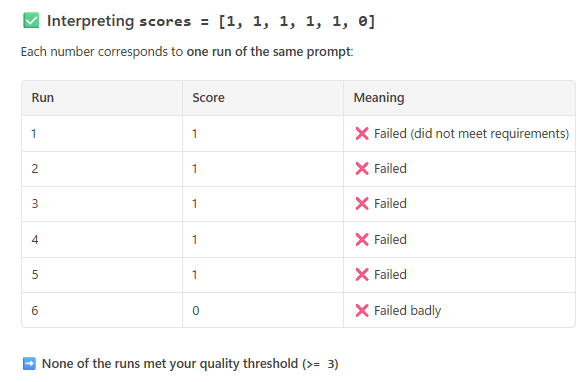

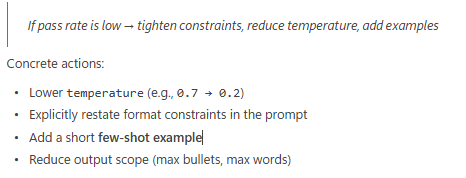

## Part H — Efficiency Tracking (Latency Baseline)

🔟 Add latency logging (simple)

Latency tracker

In [32]:
def timed_run(task, user_input):
    t0 = time.time()
    out = run_prompt(task, user_input)
    t1 = time.time()
    return out, (t1 - t0)

latencies = []
for row in golden:
    _, dt = timed_run(row["task"], row["input"])
    latencies.append({"id": row["id"], "latency_sec": round(dt, 3)})

pd.DataFrame(latencies)

,id,latency_sec
0,churn_risks_json_v1,4.645
1,ml_checklist_v1,3.594
2,prompt_chain_summary_v1,3.754


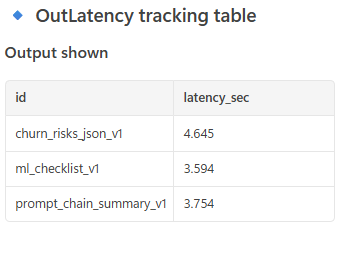

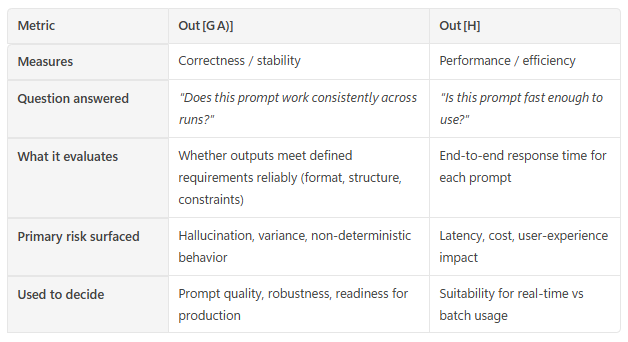

# Lab work  Module 3